# MLS Attendance & Revenue Forecasting — Exploratory Data Analysis

**Author:** Rod Alexander Pobre · Villanova University, M.S. Business Analytics & AI

This notebook explores the cleaned match-level dataset that feeds the attendance
model (`src/model.py`) and the dashboard (`src/dashboard.py`).

**Read these notes before interpreting any chart:**

- **2020 is excluded** (COVID bubble, no fans) and **2021 is flagged** `is_capacity_restricted = 1`.
- **Dates are local.** ASA reports kickoff in UTC; dates here are converted to the home market's
  local calendar day, so day-of-week and weather refer to the day the match was actually played.
- **Venue is per match.** Stadium name, listed capacity and coordinates come from the venue each
  match was played in. Listed capacity is often a reduced soccer configuration (e.g. Lumen Field,
  Mercedes-Benz Stadium), so reported attendance can legitimately exceed it; attendance is never capped.
- **Weather is observed.** Daily maximum temperature, precipitation and wind at the venue come from
  the Open-Meteo historical archive (see the `weather_source` column).
- **Ticket prices are estimates**, so revenue figures are directional. FC Cincinnati and Chivas USA
  use a $55 placeholder price.

## 1. Setup & Data Load

In [1]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
BLUE, ORANGE, GREY = '#1f77b4', '#ff7f0e', '#7f7f7f'

DATA = Path('../data/processed')
SQL = DATA / 'sql_results'

clean = pd.read_csv(DATA / 'mls_matches_clean.csv')
feats = pd.read_csv(DATA / 'model_features.csv')
print(f'Clean data: {clean.shape}')
print(f'Features:   {feats.shape}')

clean['date'] = pd.to_datetime(clean['date'])
clean['playoff'] = clean['is_playoff'].astype(int)
print('Weather source:', clean['weather_source'].value_counts().to_dict() if 'weather_source' in clean.columns else 'n/a')

def load_sql(name):
    p = SQL / f'{name}.csv'
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

print(f'Date range: {clean["date"].min().date()} to {clean["date"].max().date()}')
print(f'Seasons:    {sorted(clean["season"].unique().tolist())}')
print(f'Home teams: {clean["home_team"].nunique()}')
clean.head()

Clean data: (5403, 72)
Features:   (5403, 41)
Weather source: {'open_meteo': 5403}
Date range: 2013-03-02 to 2026-10-01
Seasons:    [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025, 2026]
Home teams: 31


,away_manager_id,away_team_id,knockout_game,penalties,attendance,home_team_id,match_id,expanded_minutes,status,last_updated_utc,...,conf_West,tier_Large,tier_Medium,stage_Early,stage_Late,stage_Mid,stage_Playoff,home_team_enc,away_team_enc,playoff
0,Xj5Yre0qbd,a2lqRX2Mr0,False,NaN,55297.0,KAqBN0Vqbg,BLMvLXZXqx,97,FullTime,2017-12-04 15:31:45 UTC,...,0,1,0,1,0,0,0,0,19,0
1,ljqExEA5x0,X0Oq66zq6D,False,NaN,45922.0,KAqBN0Vqbg,xW5pLXn65g,96,FullTime,2017-08-29 16:28:28 UTC,...,0,1,0,1,0,0,0,0,4,0
2,vzqoAjJMap,EKXMeX3Q64,False,NaN,46011.0,KAqBN0Vqbg,vzqoLk9BQa,98,FullTime,2017-09-02 19:24:04 UTC,...,0,1,0,0,0,1,0,0,8,0
3,EGMPL0yMaY,YgOMngl5wN,False,NaN,44893.0,KAqBN0Vqbg,aDQ0E3aEME,96,FullTime,2017-11-07 21:27:10 UTC,...,0,1,0,0,0,1,0,0,11,0
4,2vQ1vR0MrA,Vj58weDM8n,False,NaN,44901.0,KAqBN0Vqbg,0x5g0gPjq7,97,FullTime,2017-05-31 21:08:32 UTC,...,0,1,0,0,0,1,0,0,18,0


## 2. Attendance Distribution

Mean:       21,345
Median:     19,796
Std:         8,743
Min:         2,873
Max:        82,110


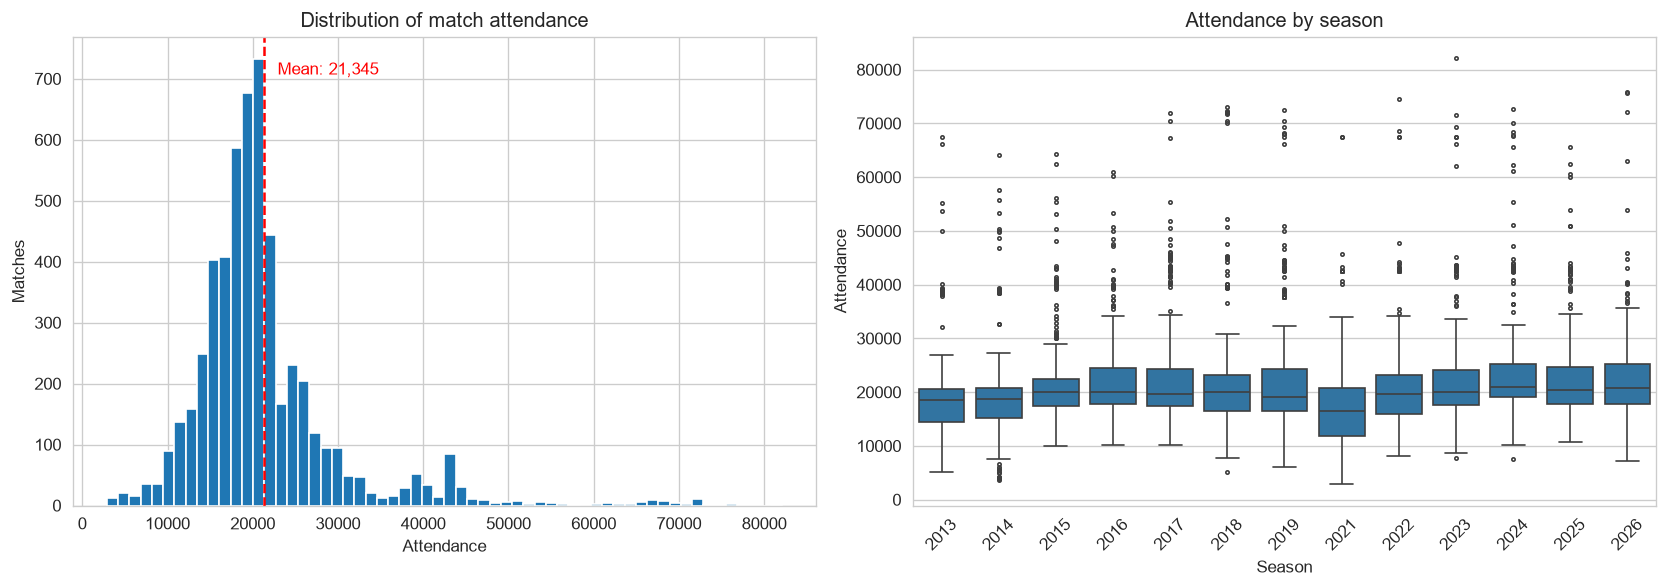

In [2]:
att = clean['attendance']
stats = att.describe()
print(f'Mean:   {att.mean():>10,.0f}')
print(f'Median: {att.median():>10,.0f}')
print(f'Std:    {att.std():>10,.0f}')
print(f'Min:    {att.min():>10,.0f}')
print(f'Max:    {att.max():>10,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(att, bins=60, color=BLUE, edgecolor='white')
axes[0].axvline(att.mean(), color='red', linestyle='--')
axes[0].annotate(f'Mean: {att.mean():,.0f}', xy=(att.mean(), axes[0].get_ylim()[1] * 0.92),
                 xytext=(8, 0), textcoords='offset points', color='red')
axes[0].set_xlabel('Attendance'); axes[0].set_ylabel('Matches')
axes[0].set_title('Distribution of match attendance')

sns.boxplot(data=clean, x='season', y='attendance', color=BLUE, fliersize=2, ax=axes[1])
axes[1].set_xlabel('Season'); axes[1].set_ylabel('Attendance')
axes[1].set_title('Attendance by season')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

The distribution is right-skewed: most matches sit in the 15,000–23,000 band typical of
soccer-specific stadiums, with a long tail from clubs playing in NFL venues (Atlanta, Seattle,
Charlotte) and occasional big-event fixtures.

## 3. Attendance Trends Over Time

season,2013,2014,2015,2016,2017,2018,2019,2021,2022,2023,2024,2025,2026
avg_attendance,18754,19352,21611,21982,22311,22174,21703,17194,21040,22202,23353,22070,22011
matches,338,335,357,357,391,408,421,383,476,517,497,524,399


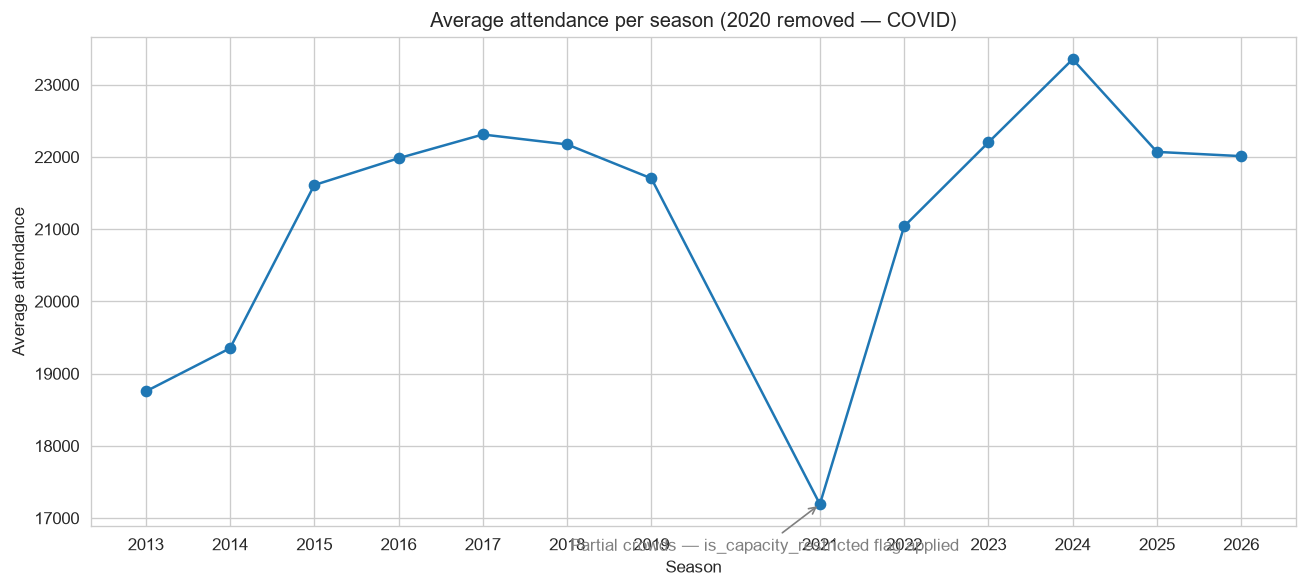

Peak season: 2024 (23,353 per match)


In [3]:
by_season = clean.groupby('season')['attendance'].agg(['mean', 'size']).rename(columns={'mean': 'avg_attendance', 'size': 'matches'})
display(by_season.round(0).astype(int).T)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(by_season.index, by_season['avg_attendance'], marker='o', color=BLUE)
ax.set_xticks(by_season.index)
ax.set_xlabel('Season'); ax.set_ylabel('Average attendance')
ax.set_title('Average attendance per season (2020 removed — COVID)')
if 2021 in by_season.index:
    ax.annotate('Partial crowds — is_capacity_restricted flag applied',
                xy=(2021, by_season.loc[2021, 'avg_attendance']),
                xytext=(-150, -28), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color=GREY), color=GREY)
last = by_season.index.max()
if clean.loc[clean['season'] == last, 'date'].max().month < 10:
    ax.annotate(f'{last}: season in progress', xy=(last, by_season.loc[last, 'avg_attendance']),
                xytext=(-95, 22), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color=GREY), color=GREY)
plt.tight_layout(); plt.show()

peak_season = int(by_season['avg_attendance'].idxmax())
print(f'Peak season: {peak_season} ({by_season.loc[peak_season, "avg_attendance"]:,.0f} per match)')

There is no 2020 point on the chart because that season was removed entirely. 2021 is the visible
dip: stadium caps were still in force for much of the year, which is why every 2021 row carries the
`is_capacity_restricted` flag.

## 4. Team-Level Analysis

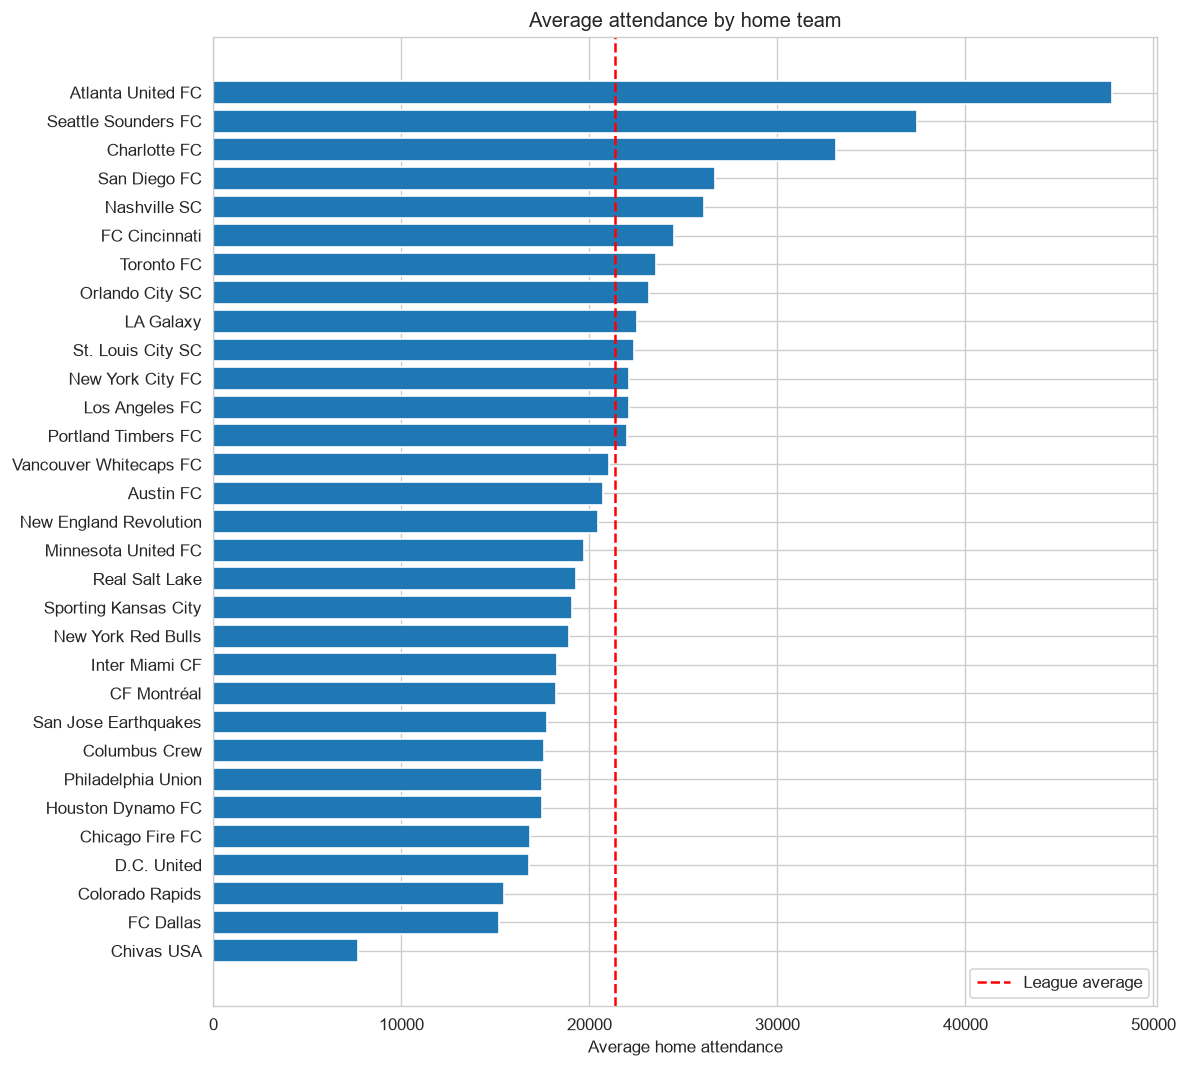

Highest: Atlanta United FC (47,821)
Lowest:  Chivas USA (7,714)
Lowest active club: FC Dallas (15,207)


In [4]:
team_avg = clean.groupby('home_team')['attendance'].mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(team_avg.index, team_avg.values, color=BLUE)
ax.axvline(clean['attendance'].mean(), color='red', linestyle='--', label='League average')
ax.set_xlabel('Average home attendance'); ax.set_title('Average attendance by home team')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

top_team, bottom_team = team_avg.index[-1], team_avg.index[0]
bottom_active = team_avg[clean.groupby('home_team')['season'].max().reindex(team_avg.index) == clean['season'].max()].index[0]
print(f'Highest: {top_team} ({team_avg.iloc[-1]:,.0f})')
print(f'Lowest:  {bottom_team} ({team_avg.iloc[0]:,.0f})')
print(f'Lowest active club: {bottom_active} ({team_avg[bottom_active]:,.0f})')

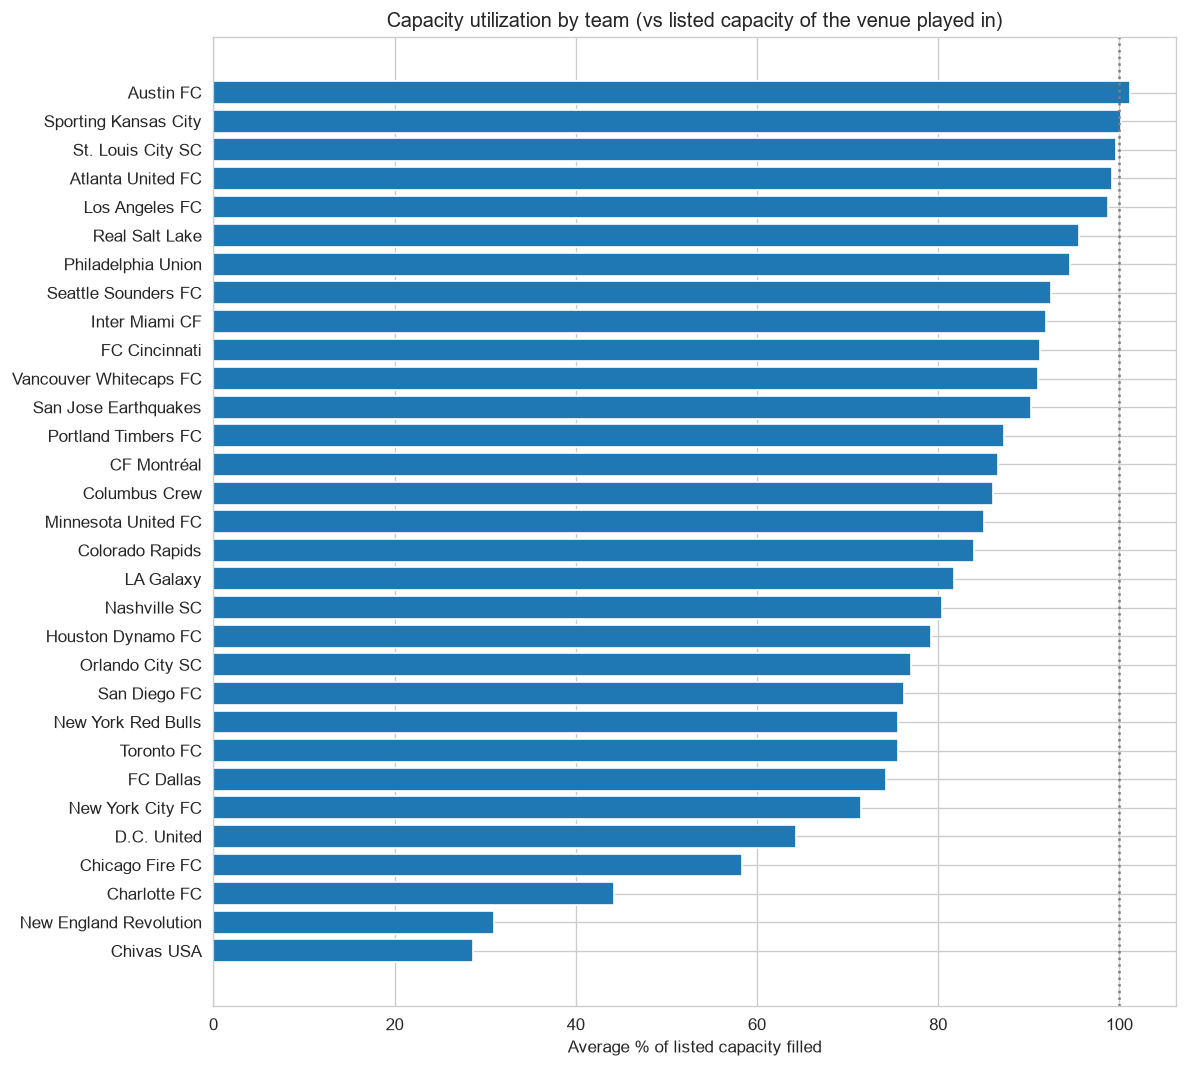

In [5]:
cap_util = load_sql('capacity_utilization')
if not cap_util.empty:
    cu = cap_util.sort_values('avg_utilization_pct')
    fig, ax = plt.subplots(figsize=(10, 9))
    ax.barh(cu['home_team'], cu['avg_utilization_pct'], color=BLUE)
    ax.axvline(100, color=GREY, linestyle=':')
    ax.set_xlabel('Average % of listed capacity filled')
    ax.set_title('Capacity utilization by team (vs listed capacity of the venue played in)')
    plt.tight_layout(); plt.show()
else:
    print('capacity_utilization.csv not found — run python src/sql_loader.py')

**Interpret utilization with care.** Each match is compared with the listed capacity of the venue it
was played in, capped at 105%. Clubs in NFL or MLB stadiums are measured against whatever capacity
ASA lists for that venue — sometimes the full bowl (New England, Charlotte), sometimes a reduced
soccer configuration (Seattle, Vancouver, NYCFC) — so cross-club comparisons are only approximate.

## 5. Home vs Away Dynamics

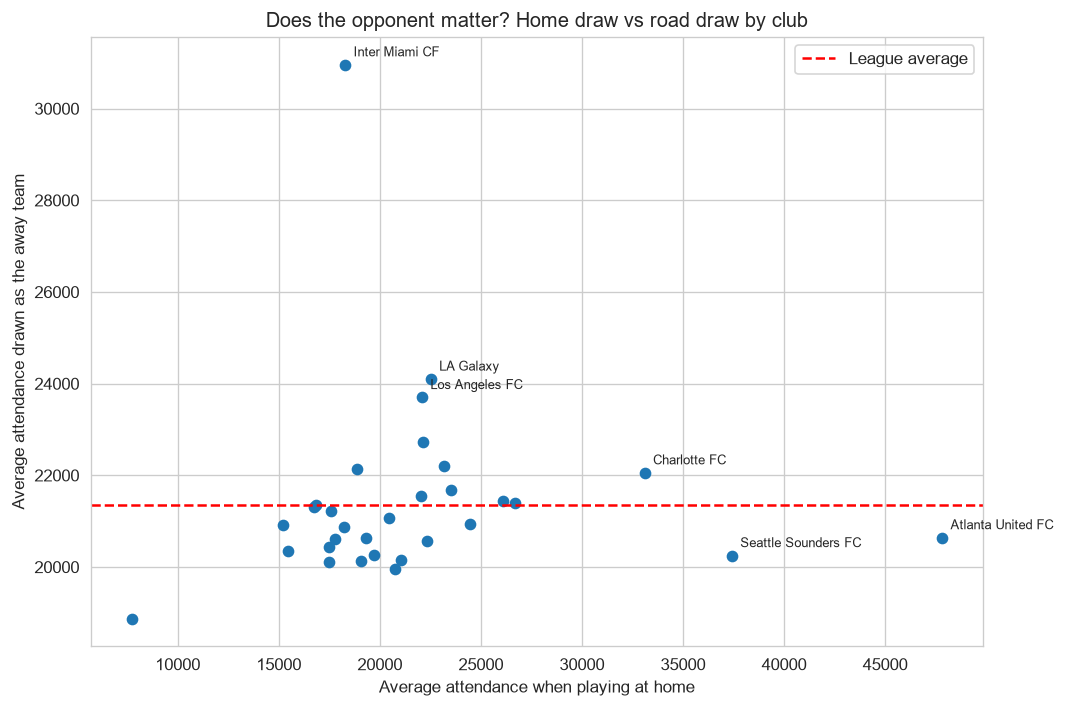

Spread across clubs as HOME team: 40,107
Spread across clubs as AWAY team: 12,086
Best road draw: Inter Miami CF (30,959 average when visiting)


In [6]:
home_mean = clean.groupby('home_team')['attendance'].mean().rename('as_home')
away_mean = clean.groupby('away_team')['attendance'].mean().rename('as_away')
ha = pd.concat([home_mean, away_mean], axis=1).dropna()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(ha['as_home'], ha['as_away'], color=BLUE)
for team in ha['as_away'].nlargest(3).index.union(ha['as_home'].nlargest(3).index):
    ax.annotate(team, (ha.loc[team, 'as_home'], ha.loc[team, 'as_away']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.axhline(clean['attendance'].mean(), color='red', linestyle='--', label='League average')
ax.set_xlabel('Average attendance when playing at home')
ax.set_ylabel('Average attendance drawn as the away team')
ax.set_title('Does the opponent matter? Home draw vs road draw by club')
ax.legend(); plt.tight_layout(); plt.show()

home_spread = ha['as_home'].max() - ha['as_home'].min()
away_spread = ha['as_away'].max() - ha['as_away'].min()
best_road = ha['as_away'].idxmax()
print(f'Spread across clubs as HOME team: {home_spread:,.0f}')
print(f'Spread across clubs as AWAY team: {away_spread:,.0f}')
print(f'Best road draw: {best_road} ({ha["as_away"].max():,.0f} average when visiting)')

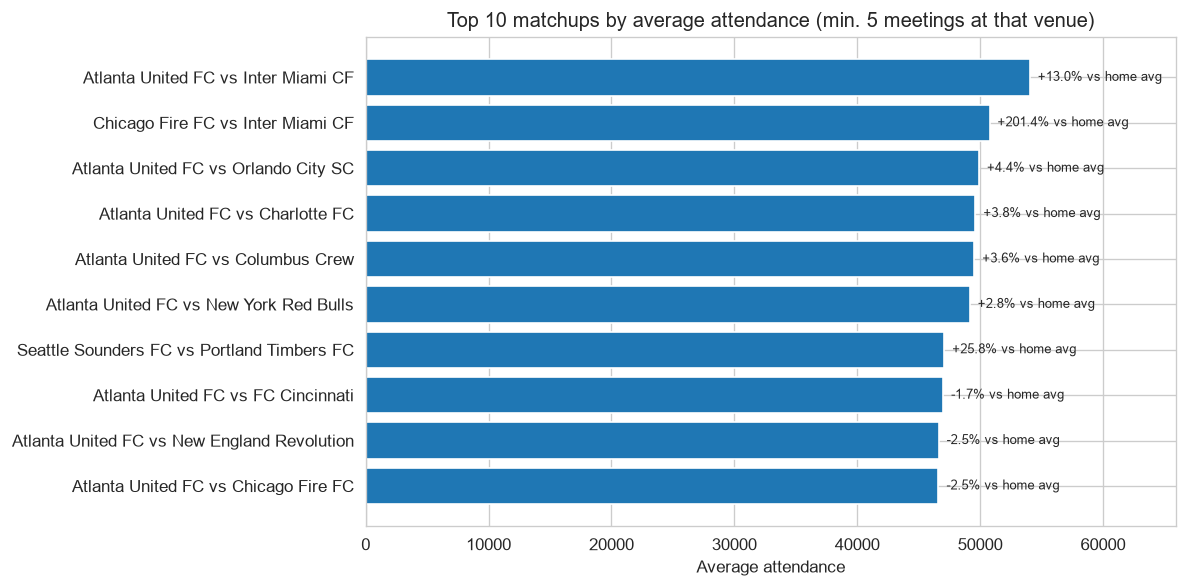

,matchup,games_played,avg_attendance,lift_vs_home_avg_pct
0,Atlanta United FC vs Inter Miami CF,7,54046.0,13.0
1,Chicago Fire FC vs Inter Miami CF,5,50761.0,201.4
2,Atlanta United FC vs Orlando City SC,10,49906.0,4.4
3,Atlanta United FC vs Charlotte FC,5,49616.0,3.8
4,Atlanta United FC vs Columbus Crew,10,49526.0,3.6
5,Atlanta United FC vs New York Red Bulls,10,49158.0,2.8
6,Seattle Sounders FC vs Portland Timbers FC,18,47081.0,25.8
7,Atlanta United FC vs FC Cincinnati,6,46986.0,-1.7
8,Atlanta United FC vs New England Revolution,10,46622.0,-2.5
9,Atlanta United FC vs Chicago Fire FC,8,46608.0,-2.5


In [7]:
riv = load_sql('top_rivalries')
if not riv.empty:
    r = riv.sort_values('avg_attendance')
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(r['matchup'], r['avg_attendance'], color=BLUE)
    for y, (v, lift) in enumerate(zip(r['avg_attendance'], r['lift_vs_home_avg_pct'])):
        ax.text(v, y, f'  {lift:+.1f}% vs home avg', va='center', fontsize=8)
    ax.set_xlim(0, r['avg_attendance'].max() * 1.22)
    ax.set_xlabel('Average attendance')
    ax.set_title('Top 10 matchups by average attendance (min. 5 meetings at that venue)')
    plt.tight_layout(); plt.show()
    display(riv[['matchup', 'games_played', 'avg_attendance', 'lift_vs_home_avg_pct']])
else:
    print('top_rivalries.csv not found — run python src/sql_loader.py')

Who hosts matters far more than who visits: the spread in average attendance across home clubs is
several times the spread across away clubs. The top-10 list is dominated by the clubs with the
largest venues, which is why the *lift over the home club's own average* (the label on each bar) is
the more useful measure of how much a particular opponent moves the crowd.

## 6. Weather & Calendar Effects

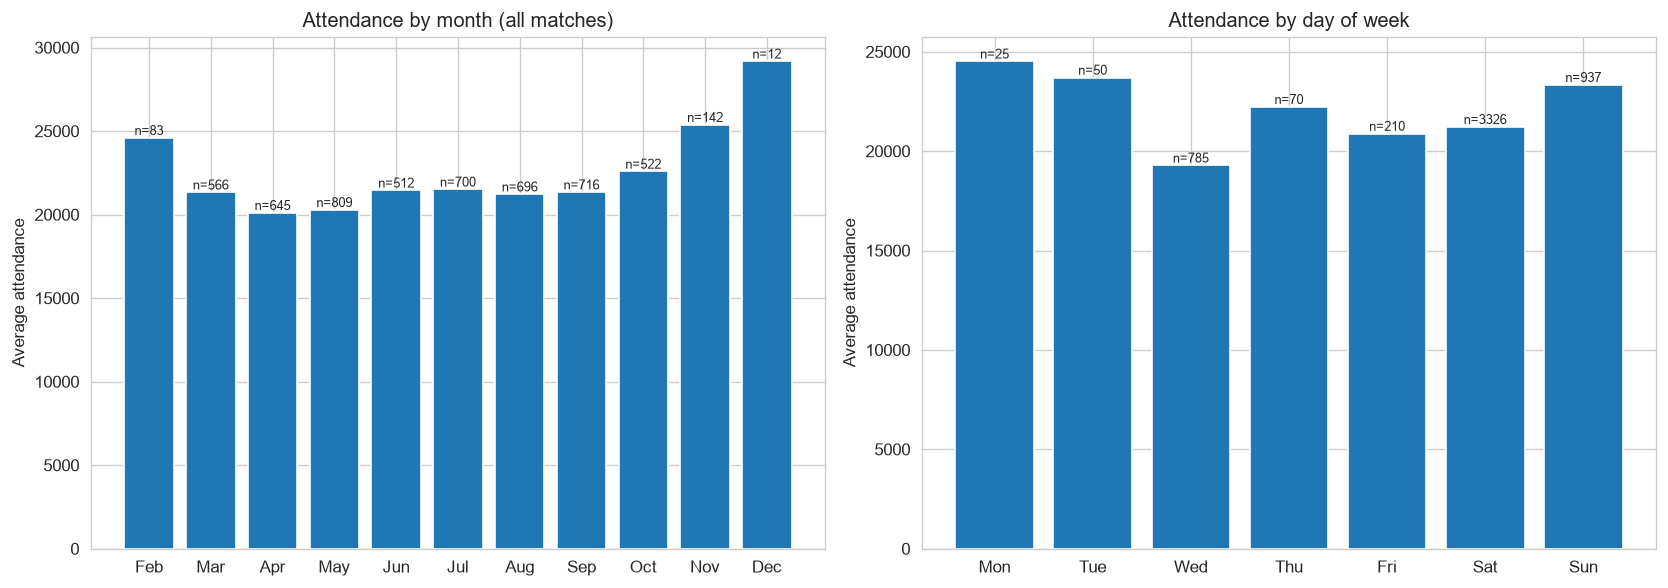

Regular season, Jun-Aug: 21,387 | Mar-May: 20,522 | difference: +4.2%
Weekend: 21,686 | Weekday: 20,066 | difference: +8.1%


In [8]:
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

by_month = clean.groupby('month')['attendance'].agg(['mean', 'size'])
by_dow = clean.groupby('day_of_week')['attendance'].agg(['mean', 'size'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar([month_names[m] for m in by_month.index], by_month['mean'], color=BLUE)
for i, n in enumerate(by_month['size']):
    axes[0].text(i, by_month['mean'].iloc[i], f'n={n}', ha='center', va='bottom', fontsize=8)
axes[0].set_ylabel('Average attendance'); axes[0].set_title('Attendance by month (all matches)')

axes[1].bar([day_names[d] for d in by_dow.index], by_dow['mean'], color=BLUE)
for i, n in enumerate(by_dow['size']):
    axes[1].text(i, by_dow['mean'].iloc[i], f'n={n}', ha='center', va='bottom', fontsize=8)
axes[1].set_ylabel('Average attendance'); axes[1].set_title('Attendance by day of week')
plt.tight_layout(); plt.show()

reg = clean[clean['playoff'] == 0]
summer = reg.loc[reg['month'].isin([6, 7, 8]), 'attendance'].mean()
spring = reg.loc[reg['month'].isin([3, 4, 5]), 'attendance'].mean()
summer_vs_spring_pct = (summer - spring) / spring * 100
wk = clean.groupby('is_weekend')['attendance'].mean()
weekend_pct = (wk[1] - wk[0]) / wk[0] * 100
print(f'Regular season, Jun-Aug: {summer:,.0f} | Mar-May: {spring:,.0f} | difference: {summer_vs_spring_pct:+.1f}%')
print(f'Weekend: {wk[1]:,.0f} | Weekday: {wk[0]:,.0f} | difference: {weekend_pct:+.1f}%')

Late-season months include playoff matches and season finales, and February is home openers only,
so both sit on small, unrepresentative samples. The printed figures above give the regular-season
summer-vs-spring and the weekend-vs-weekday differences.

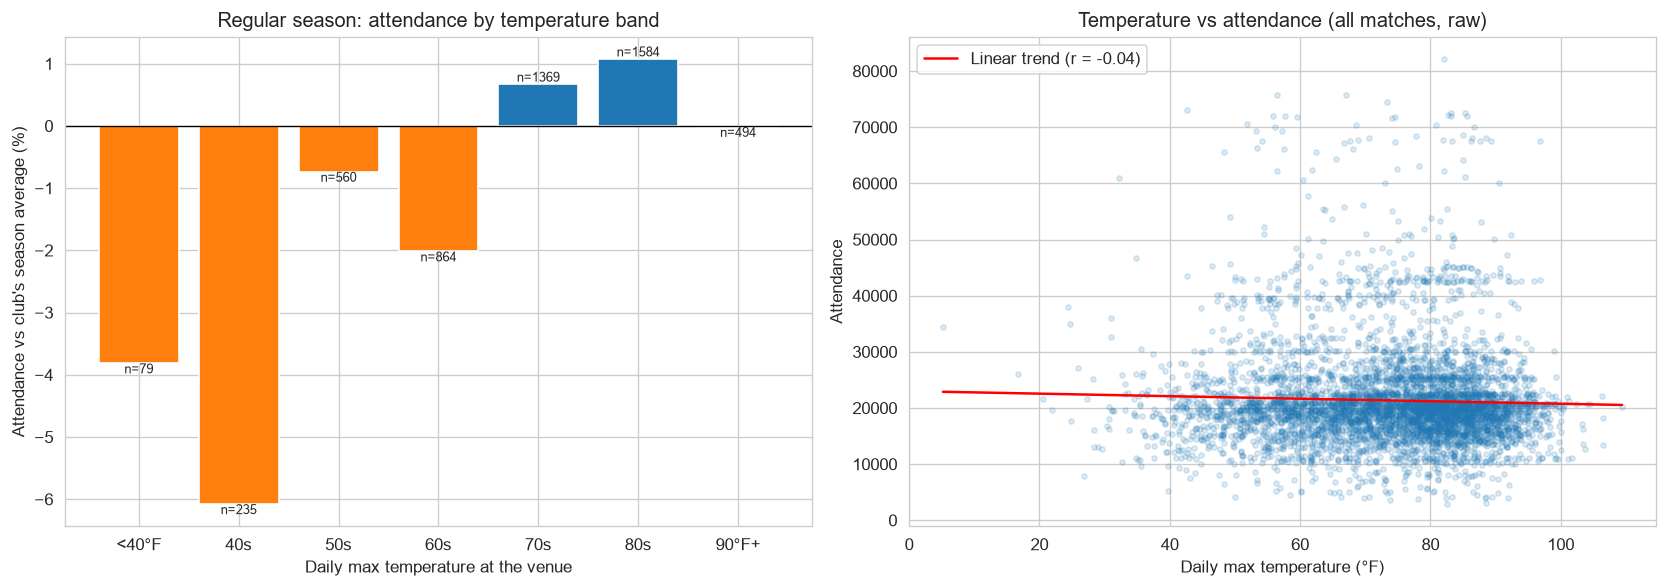

Mean daily max temperature by month (°F): {2: 57, 3: 58, 4: 65, 5: 72, 6: 81, 7: 85, 8: 84, 9: 78, 10: 69, 11: 58, 12: 51}
Below 40°F: -3.8% vs club season average (n=79)
90°F and above: -0.0% (n=494)
Rainy days (>5 mm): -1.9% (n=900) | dry days: +0.1%


In [9]:
# Weather: compare each match with the SAME club's average that season, so that
# cold-weather cities or big-stadium clubs do not masquerade as a weather effect.
clean['temp_f'] = clean['temperature_max'] * 9 / 5 + 32
clean['rel_att'] = clean['attendance'] / clean.groupby(['home_team', 'season'])['attendance'].transform('mean') - 1
labels = ['<40°F', '40s', '50s', '60s', '70s', '80s', '90°F+']
clean['temp_bucket'] = pd.cut(clean['temp_f'], bins=[-60, 40, 50, 60, 70, 80, 90, 160], labels=labels, right=False)
reg = clean[clean['playoff'] == 0]

tb = reg.groupby('temp_bucket', observed=True)['rel_att'].agg(['mean', 'size'])
rain = reg.groupby('is_rainy')['rel_att'].agg(['mean', 'size'])
temp_corr = clean['temp_f'].corr(clean['attendance'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(tb.index.astype(str), tb['mean'] * 100, color=[ORANGE if v < 0 else BLUE for v in tb['mean']])
axes[0].axhline(0, color='black', linewidth=0.8)
for i, (v, n) in enumerate(zip(tb['mean'] * 100, tb['size'])):
    axes[0].text(i, v, f'n={n}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)
axes[0].set_xlabel('Daily max temperature at the venue')
axes[0].set_ylabel("Attendance vs club's season average (%)")
axes[0].set_title('Regular season: attendance by temperature band')

slope, intercept = np.polyfit(clean['temp_f'], clean['attendance'], 1)
xs = np.linspace(clean['temp_f'].min(), clean['temp_f'].max(), 50)
axes[1].scatter(clean['temp_f'], clean['attendance'], alpha=0.15, s=10, color=BLUE)
axes[1].plot(xs, slope * xs + intercept, color='red', label=f'Linear trend (r = {temp_corr:.2f})')
axes[1].set_xlabel('Daily max temperature (°F)'); axes[1].set_ylabel('Attendance')
axes[1].set_title('Temperature vs attendance (all matches, raw)')
axes[1].legend()
plt.tight_layout(); plt.show()

cold_pct = tb.loc['<40°F', 'mean'] * 100 if '<40°F' in tb.index else float('nan')
hot_pct = tb.loc['90°F+', 'mean'] * 100 if '90°F+' in tb.index else float('nan')
rain_pct = rain.loc[1, 'mean'] * 100 if 1 in rain.index else float('nan')
dry_pct = rain.loc[0, 'mean'] * 100
print('Mean daily max temperature by month (°F):', clean.groupby('month')['temp_f'].mean().round(0).astype(int).to_dict())
print(f'Below 40°F: {cold_pct:+.1f}% vs club season average (n={int(tb.loc["<40°F", "size"]) if "<40°F" in tb.index else 0})')
print(f'90°F and above: {hot_pct:+.1f}% (n={int(tb.loc["90°F+", "size"]) if "90°F+" in tb.index else 0})')
print(f'Rainy days (>5 mm): {rain_pct:+.1f}% (n={int(rain.loc[1, "size"]) if 1 in rain.index else 0}) | dry days: {dry_pct:+.1f}%')

Weather effects are measured against each club's own season average, which removes the fact that
some clubs simply play in colder or wetter cities. Keep in mind that MLS reports **announced
attendance** (tickets distributed), so bad weather on the day mostly shows up as no-shows that this
figure does not capture — the true effect on people in seats is likely larger than what is visible here.

## 7. Playoff Premium

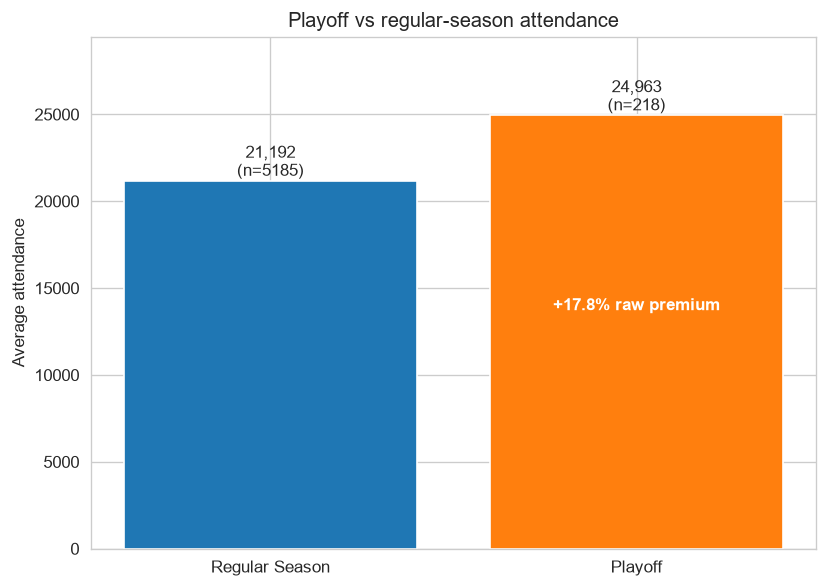

Raw playoff premium:              +17.8%
Like-for-like (same club & season): +8.1%  across 127 club-seasons


In [10]:
po = load_sql('playoff_vs_regular')
if po.empty:
    po = (clean.assign(match_type=np.where(clean['playoff'] == 1, 'Playoff', 'Regular Season'))
               .groupby('match_type')['attendance'].agg(avg_attendance='mean', games_played='size').reset_index())
po = po.set_index('match_type')
raw_premium_pct = (po.loc['Playoff', 'avg_attendance'] / po.loc['Regular Season', 'avg_attendance'] - 1) * 100

# Like-for-like: same club, same season
ts = clean.pivot_table(index=['home_team', 'season'], columns='playoff', values='attendance', aggfunc='mean').dropna()
matched_premium_pct = ((ts[1] - ts[0]) / ts[0]).mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
order = ['Regular Season', 'Playoff']
bars = ax.bar(order, po.loc[order, 'avg_attendance'], color=[BLUE, ORANGE])
for b, name in zip(bars, order):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f'{b.get_height():,.0f}\n(n={int(po.loc[name, "games_played"])})', ha='center', va='bottom')
ax.annotate(f'+{raw_premium_pct:.1f}% raw premium', xy=(1, po.loc['Playoff', 'avg_attendance'] * 0.55),
            ha='center', color='white', fontweight='bold')
ax.set_ylim(0, po['avg_attendance'].max() * 1.18)
ax.set_ylabel('Average attendance'); ax.set_title('Playoff vs regular-season attendance')
plt.tight_layout(); plt.show()

print(f'Raw playoff premium:              {raw_premium_pct:+.1f}%')
print(f'Like-for-like (same club & season): {matched_premium_pct:+.1f}%  across {len(ts)} club-seasons')

The raw premium overstates the effect because playoff hosts are, by definition, the better-supported
and more successful clubs. Comparing each club's playoff home games with its *own* regular-season
average in the same year gives a smaller, more defensible premium.

## 8. Feature Correlation with Attendance

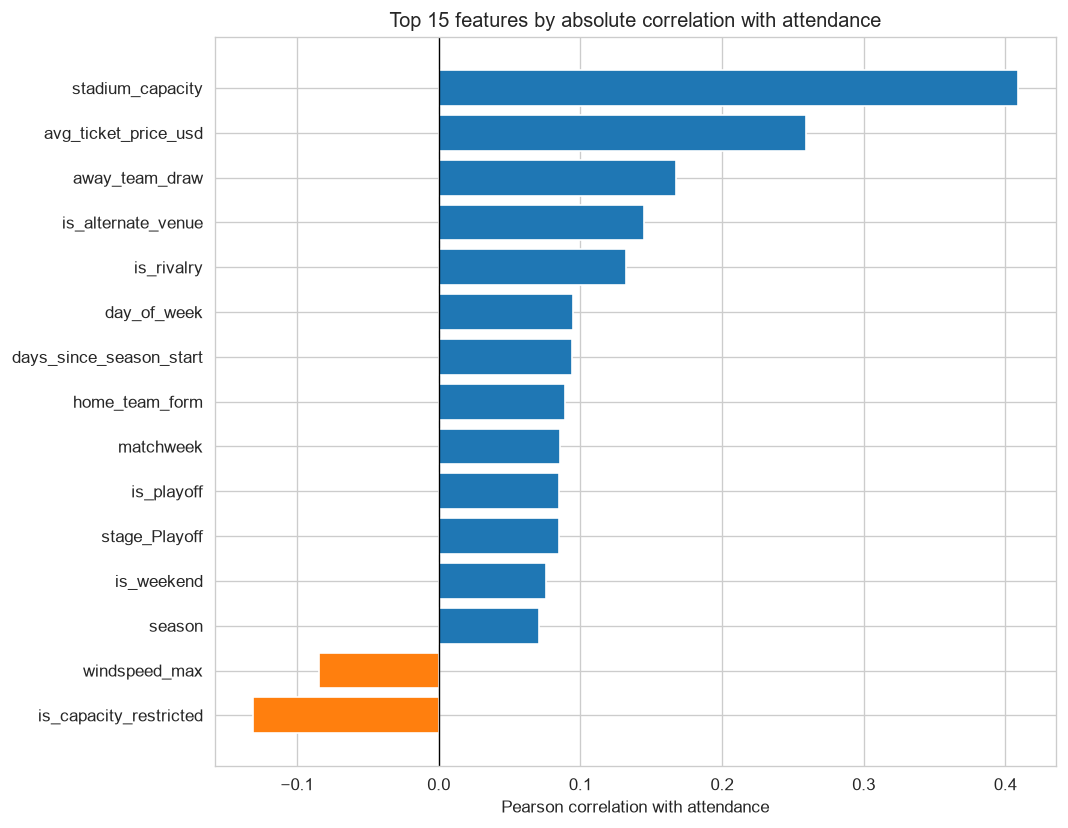

Most positively correlated:
stadium_capacity        0.409
avg_ticket_price_usd    0.259
away_team_draw          0.167
is_alternate_venue      0.145
is_rivalry              0.132

Most negatively correlated:
is_capacity_restricted   -0.131
windspeed_max            -0.084
conf_West                -0.063
tier_Large               -0.055
metro_population         -0.053


In [11]:
LEAKAGE = ['attendance_pct', 'estimated_revenue', 'goal_diff']   # known only after the match
num = feats.select_dtypes(include='number').drop(columns=LEAKAGE, errors='ignore')
num = num.loc[:, num.nunique() > 1]
corr = num.corr()['attendance'].drop('attendance').sort_values()
top15 = corr.reindex(corr.abs().sort_values(ascending=False).head(15).index).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top15.index, top15.values, color=[ORANGE if v < 0 else BLUE for v in top15.values])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with attendance')
ax.set_title('Top 15 features by absolute correlation with attendance')
plt.tight_layout(); plt.show()

print('Most positively correlated:'); print(corr.sort_values(ascending=False).head(5).round(3).to_string())
print('\nMost negatively correlated:'); print(corr.head(5).round(3).to_string())

`attendance_pct`, `estimated_revenue` and `goal_diff` are left out: the first two are computed
directly from attendance and the third is the final score, so none is available before kick-off.
Venue and club-level features dominate; match-level factors show much weaker linear relationships.

## 9. Key Findings Summary

In [12]:
first_season, last_season = int(clean['season'].min()), int(clean['season'].max())
top_corr_feature = corr.abs().idxmax()
findings = f'''
- **League-wide average attendance is {att.mean():,.0f} per match** (median {att.median():,.0f}) across {len(clean):,} matches, {first_season}–{last_season}, excluding 2020.
- **Attendance peaked in {peak_season} at {by_season.loc[peak_season, "avg_attendance"]:,.0f} per match**; the capacity-restricted 2021 season averaged {by_season.loc[2021, "avg_attendance"]:,.0f}.
- **{top_team} leads the league at {team_avg.iloc[-1]:,.0f} per home match**; the lowest active club is {bottom_active} at {team_avg[bottom_active]:,.0f}.
- **The home club matters far more than the visitor:** average attendance spans {home_spread:,.0f} across home clubs but only {away_spread:,.0f} across away clubs. {best_road} is the best road draw ({ha["as_away"].max():,.0f}).
- **Playoff matches draw {raw_premium_pct:.1f}% more than regular-season matches in the raw data, but only {matched_premium_pct:.1f}% more like-for-like** (same club, same season).
- **Calendar effects:** weekend matches draw {weekend_pct:.1f}% more than weekday matches, and regular-season summer (Jun–Aug) matches draw {summer_vs_spring_pct:.1f}% more than spring (Mar–May) matches.
- **Weather has only a modest effect on announced attendance:** relative to the same club's season average, matches below 40°F draw {cold_pct:+.1f}%, matches at 90°F or above {hot_pct:+.1f}%, and rainy days (>5 mm) {rain_pct:+.1f}%.
- **`{top_corr_feature}` is the strongest single correlate of attendance (r = {corr[top_corr_feature]:.2f}).**
'''
display(Markdown(findings))


- **League-wide average attendance is 21,345 per match** (median 19,796) across 5,403 matches, 2013–2026, excluding 2020.
- **Attendance peaked in 2024 at 23,353 per match**; the capacity-restricted 2021 season averaged 17,194.
- **Atlanta United FC leads the league at 47,821 per home match**; the lowest active club is FC Dallas at 15,207.
- **The home club matters far more than the visitor:** average attendance spans 40,107 across home clubs but only 12,086 across away clubs. Inter Miami CF is the best road draw (30,959).
- **Playoff matches draw 17.8% more than regular-season matches in the raw data, but only 8.1% more like-for-like** (same club, same season).
- **Calendar effects:** weekend matches draw 8.1% more than weekday matches, and regular-season summer (Jun–Aug) matches draw 4.2% more than spring (Mar–May) matches.
- **Weather has only a modest effect on announced attendance:** relative to the same club's season average, matches below 40°F draw -3.8%, matches at 90°F or above -0.0%, and rainy days (>5 mm) -1.9%.
- **`stadium_capacity` is the strongest single correlate of attendance (r = 0.41).**
